In [86]:
import pandas as pd

df = pd.read_excel(
    r"C:\Users\Caio Ladeira\OneDrive\Área de Trabalho\portifolio\DadosPetroleo\Data\raw\semanal-estados-desde-2013.xlsx",
    skiprows=17 #ignora as 17 primeiras linhas, pois ela so tem a especificação delas
)

df.head()
df.info()

#carrega a tabela 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111723 entries, 0 to 111722
Data columns (total 18 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   DATA INICIAL                   111723 non-null  datetime64[ns]
 1   DATA FINAL                     111723 non-null  datetime64[ns]
 2   REGIÃO                         111723 non-null  object        
 3   ESTADO                         111723 non-null  object        
 4   PRODUTO                        111723 non-null  object        
 5   NÚMERO DE POSTOS PESQUISADOS   111723 non-null  int64         
 6   UNIDADE DE MEDIDA              111723 non-null  object        
 7   PREÇO MÉDIO REVENDA            111723 non-null  float64       
 8   DESVIO PADRÃO REVENDA          111723 non-null  float64       
 9   PREÇO MÍNIMO REVENDA           111723 non-null  float64       
 10  PREÇO MÁXIMO REVENDA           111723 non-null  float64       
 11  

In [87]:
import numpy as np

df = df.replace("-", np.nan)
#remove os valores vazios

C:\Users\Caio Ladeira\AppData\Local\Temp\ipykernel_8420\651052528.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace("-", np.nan)


In [88]:
colunas_distribuicao = [
    "MARGEM MÉDIA REVENDA",
    "PREÇO MÉDIO DISTRIBUIÇÃO",
    "DESVIO PADRÃO DISTRIBUIÇÃO",
    "PREÇO MÍNIMO DISTRIBUIÇÃO",
    "PREÇO MÁXIMO DISTRIBUIÇÃO",
    "COEF DE VARIAÇÃO DISTRIBUIÇÃO"
] #agrupa tudo que é número

for col in colunas_distribuicao:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111723 entries, 0 to 111722
Data columns (total 18 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   DATA INICIAL                   111723 non-null  datetime64[ns]
 1   DATA FINAL                     111723 non-null  datetime64[ns]
 2   REGIÃO                         111723 non-null  object        
 3   ESTADO                         111723 non-null  object        
 4   PRODUTO                        111723 non-null  object        
 5   NÚMERO DE POSTOS PESQUISADOS   111723 non-null  int64         
 6   UNIDADE DE MEDIDA              111723 non-null  object        
 7   PREÇO MÉDIO REVENDA            111723 non-null  float64       
 8   DESVIO PADRÃO REVENDA          111723 non-null  float64       
 9   PREÇO MÍNIMO REVENDA           111723 non-null  float64       
 10  PREÇO MÁXIMO REVENDA           111723 non-null  float64       
 11  

In [89]:
df["PRODUTO"].unique() #tipos de combustível disponível

array(['ETANOL HIDRATADO', 'GASOLINA COMUM', 'GLP', 'GNV', 'OLEO DIESEL',
       'OLEO DIESEL S10', 'GASOLINA ADITIVADA'], dtype=object)

In [90]:
df_diesel = df[df["PRODUTO"] == "OLEO DIESEL S10"].copy() #define o ponto de pesquisa

In [91]:
df_diesel = df_diesel[
    df_diesel["DATA INICIAL"] >= "2021-01-01"
] #filtra os ultimos 5 anos

In [92]:
df_diesel.head()

,DATA INICIAL,DATA FINAL,REGIÃO,ESTADO,PRODUTO,NÚMERO DE POSTOS PESQUISADOS,UNIDADE DE MEDIDA,PREÇO MÉDIO REVENDA,DESVIO PADRÃO REVENDA,PREÇO MÍNIMO REVENDA,PREÇO MÁXIMO REVENDA,MARGEM MÉDIA REVENDA,COEF DE VARIAÇÃO REVENDA,PREÇO MÉDIO DISTRIBUIÇÃO,DESVIO PADRÃO DISTRIBUIÇÃO,PREÇO MÍNIMO DISTRIBUIÇÃO,PREÇO MÁXIMO DISTRIBUIÇÃO,COEF DE VARIAÇÃO DISTRIBUIÇÃO
62337,2021-01-03,2021-01-09,NORTE,ACRE,OLEO DIESEL S10,27,R$/l,4.590,0.107,4.36,4.850,NaN,0.023,NaN,NaN,NaN,NaN,NaN
62338,2021-01-03,2021-01-09,NORDESTE,ALAGOAS,OLEO DIESEL S10,29,R$/l,3.982,0.121,3.63,4.199,NaN,0.030,NaN,NaN,NaN,NaN,NaN
62339,2021-01-03,2021-01-09,NORTE,AMAPA,OLEO DIESEL S10,13,R$/l,4.290,0.104,4.19,4.540,NaN,0.024,NaN,NaN,NaN,NaN,NaN
62340,2021-01-03,2021-01-09,NORTE,AMAZONAS,OLEO DIESEL S10,48,R$/l,3.800,0.152,3.63,4.190,NaN,0.040,NaN,NaN,NaN,NaN,NaN
62341,2021-01-03,2021-01-09,NORDESTE,BAHIA,OLEO DIESEL S10,101,R$/l,3.704,0.165,3.49,3.999,NaN,0.045,NaN,NaN,NaN,NaN,NaN


In [93]:
df_diesel.shape

(7494, 18)

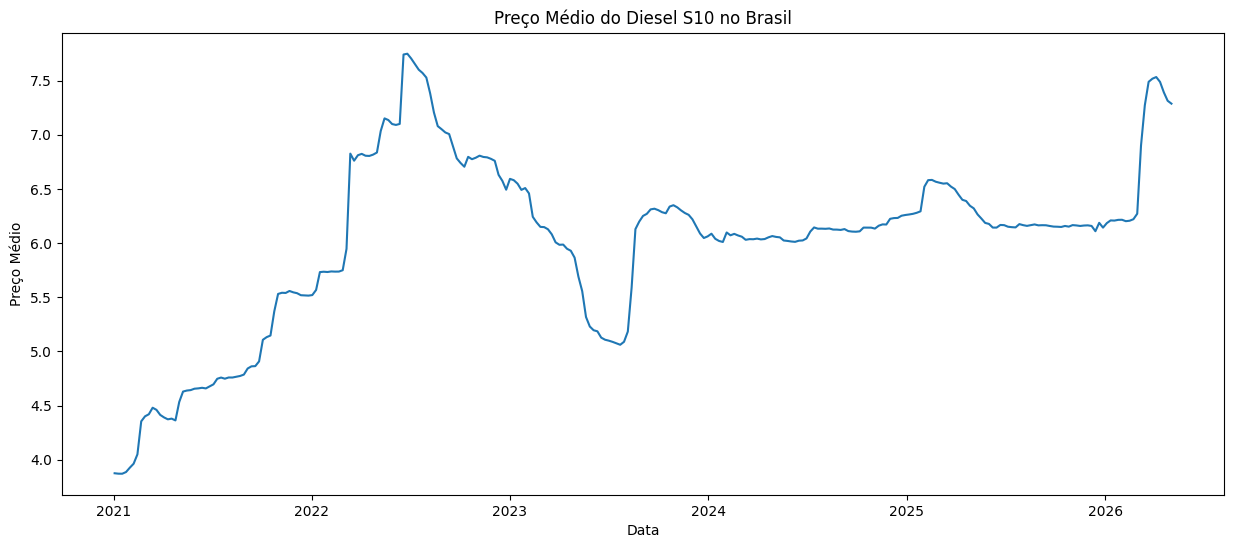

In [94]:
import matplotlib.pyplot as plt
media_tempo = (
    df_diesel
    .groupby("DATA INICIAL")["PREÇO MÉDIO REVENDA"]
    .mean()
)
plt.figure(figsize=(15,6))

plt.plot(media_tempo.index, media_tempo.values)

plt.title("Preço Médio do Diesel S10 no Brasil")
plt.xlabel("Data")
plt.ylabel("Preço Médio")

plt.show() #Primeiro grafico

In [95]:
volatilidade_estado = (
    df_diesel
    .groupby("ESTADO")["COEF DE VARIAÇÃO REVENDA"]
    .mean()
    .sort_values(ascending=False)
)

volatilidade_estado.head(10) #encontrar os estados mais imprevisíveis

ESTADO
AMAZONAS              0.075637
PARA                  0.066784
SAO PAULO             0.058040
ALAGOAS               0.057525
MATO GROSSO DO SUL    0.051115
BAHIA                 0.048950
RIO GRANDE DO SUL     0.047547
RIO DE JANEIRO        0.047482
CEARA                 0.046248
RONDONIA              0.044047
Name: COEF DE VARIAÇÃO REVENDA, dtype: float64

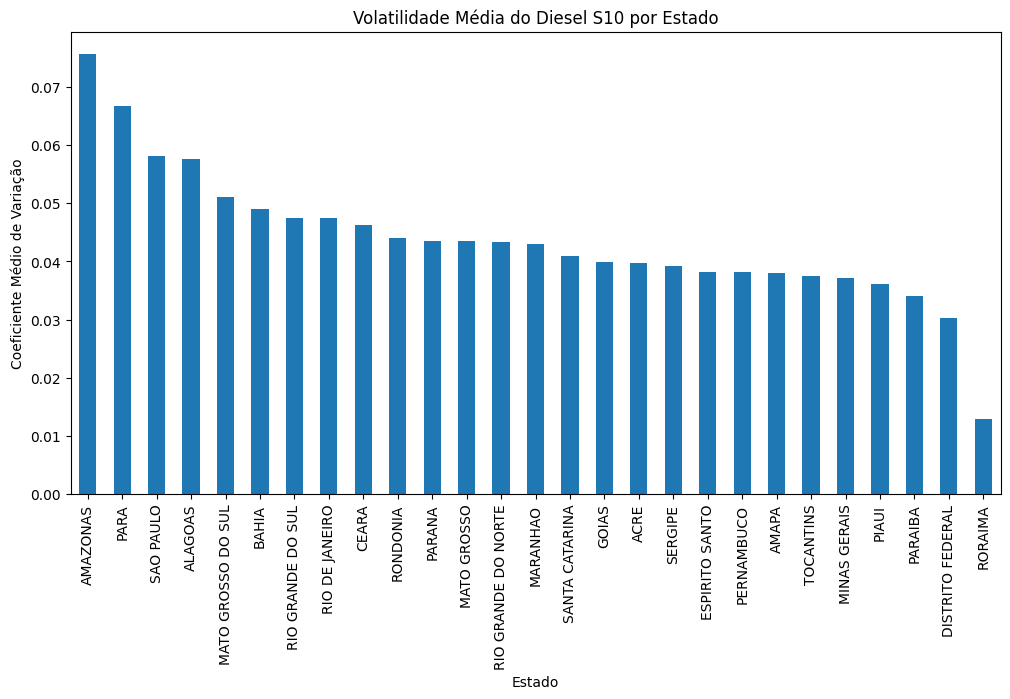

In [96]:
plt.figure(figsize=(12,6))

volatilidade_estado.plot(kind="bar")

plt.title("Volatilidade Média do Diesel S10 por Estado")
plt.xlabel("Estado")
plt.ylabel("Coeficiente Médio de Variação")

plt.show()

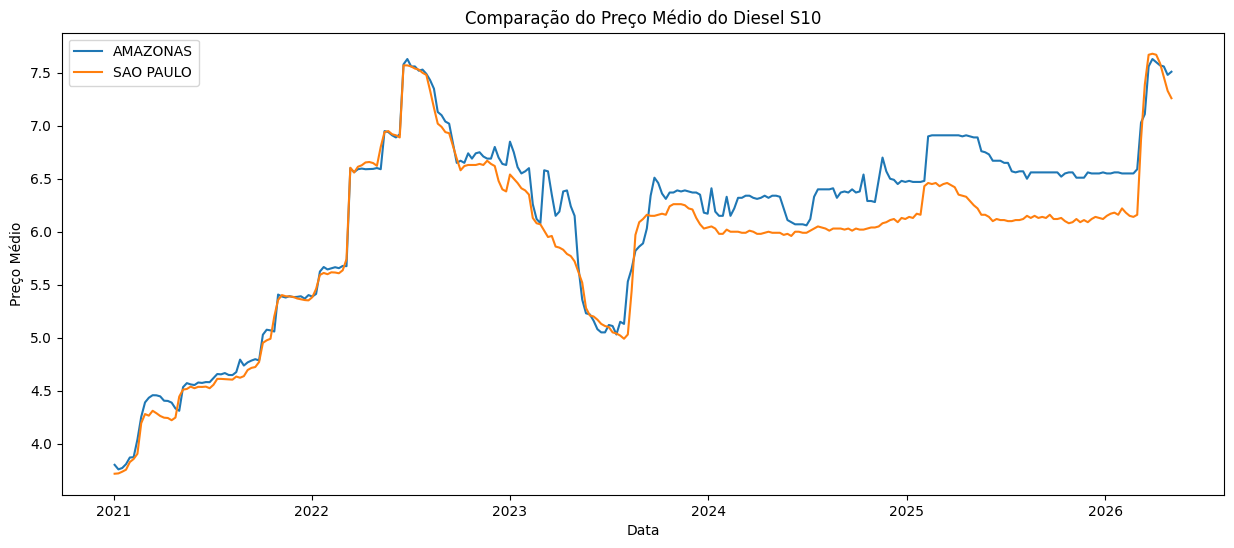

In [97]:
estados = ["AMAZONAS", "SAO PAULO"]

df_estados = df_diesel[
    df_diesel["ESTADO"].isin(estados)
]
plt.figure(figsize=(15,6))

for estado in estados:
    subset = df_estados[df_estados["ESTADO"] == estado]

    plt.plot(
        subset["DATA INICIAL"],
        subset["PREÇO MÉDIO REVENDA"],
        label=estado
    )

plt.title("Comparação do Preço Médio do Diesel S10")
plt.xlabel("Data")
plt.ylabel("Preço Médio")

plt.legend()

plt.show()
# O que tirar do grágico: Amazonas mantém preço consistentemente acima de São Paulo na maior parte da série.
# Os movimentos macroeconômicos são quase sincronizados.
#Amazonas parece ter maior ruído local.

In [98]:
df_diesel = df_diesel.sort_values(
    ["ESTADO", "DATA INICIAL"]
)

df_diesel["VARIACAO_SEMANAL"] = (
    df_diesel
    .groupby("ESTADO")["PREÇO MÉDIO REVENDA"]
    .pct_change()
)

In [99]:
df_diesel[
    [
        "ESTADO",
        "DATA INICIAL",
        "PREÇO MÉDIO REVENDA",
        "VARIACAO_SEMANAL"
    ]
].head(10)

,ESTADO,DATA INICIAL,PREÇO MÉDIO REVENDA,VARIACAO_SEMANAL
62337,ACRE,2021-01-03,4.590,NaN
62513,ACRE,2021-01-10,4.617,0.005882
62689,ACRE,2021-01-17,4.681,0.013862
62865,ACRE,2021-01-24,4.604,-0.016449
63042,ACRE,2021-01-31,4.638,0.007385
63219,ACRE,2021-02-07,4.701,0.013583
63396,ACRE,2021-02-14,4.806,0.022336
63573,ACRE,2021-02-21,5.084,0.057844
63753,ACRE,2021-02-28,5.159,0.014752
63933,ACRE,2021-03-07,5.182,0.004458


In [100]:
amazonas = df_diesel[
    df_diesel["ESTADO"] == "AMAZONAS"
]

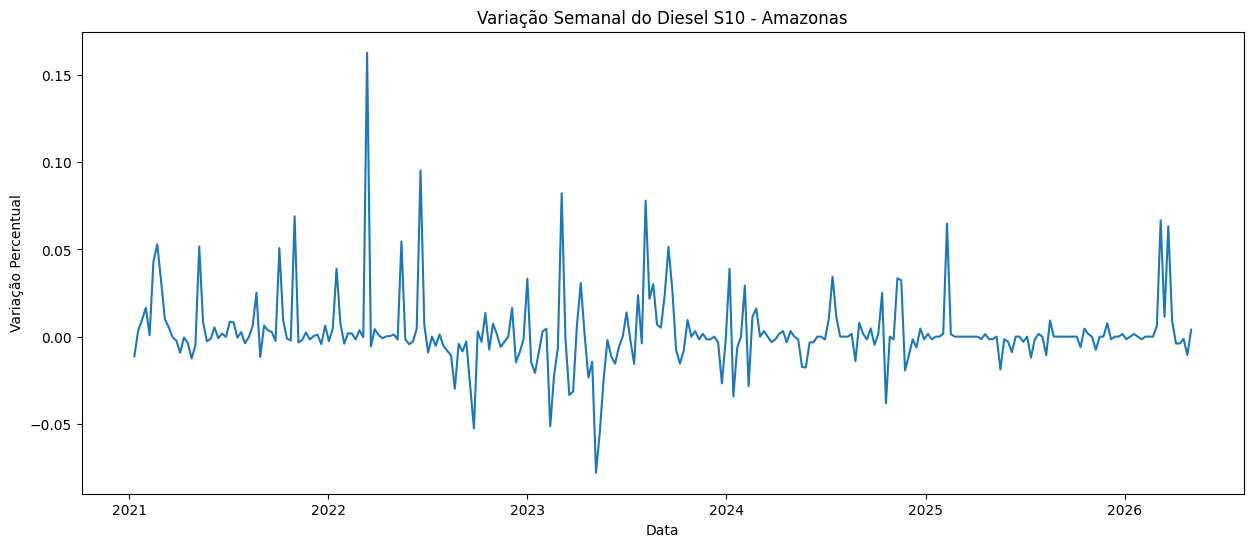

In [101]:
plt.figure(figsize=(15,6))

plt.plot(
    amazonas["DATA INICIAL"],
    amazonas["VARIACAO_SEMANAL"]
)

plt.title("Variação Semanal do Diesel S10 - Amazonas")
plt.xlabel("Data")
plt.ylabel("Variação Percentual")

plt.show()

In [102]:
df_diesel["VARIACAO_SEMANAL"].describe()

count    7467.000000
mean        0.002506
std         0.021368
min        -0.111380
25%        -0.004975
50%         0.000000
75%         0.004858
max         0.200304
Name: VARIACAO_SEMANAL, dtype: float64

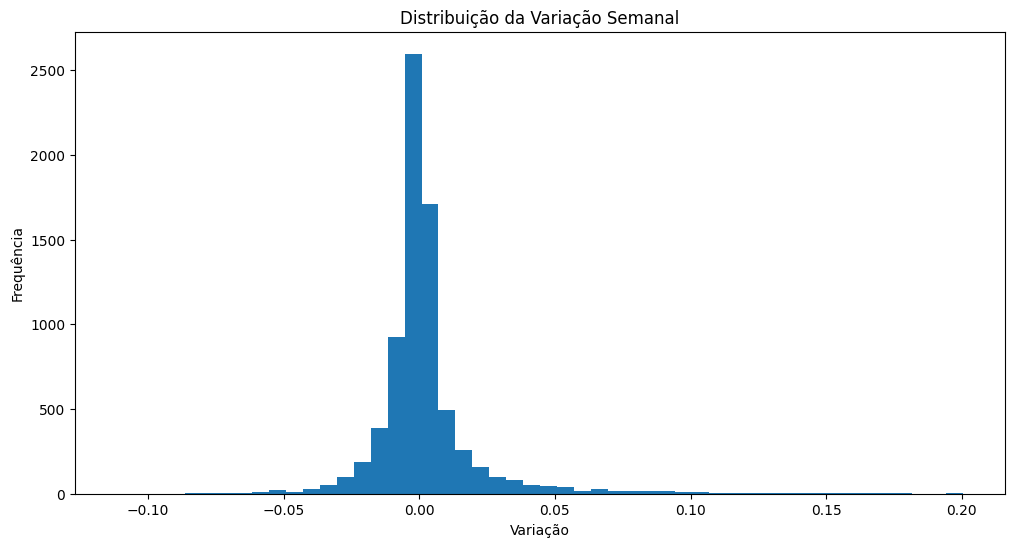

In [103]:
plt.figure(figsize=(12,6))

plt.hist(
    df_diesel["VARIACAO_SEMANAL"].dropna(),
    bins=50
)

plt.title("Distribuição da Variação Semanal")
plt.xlabel("Variação")
plt.ylabel("Frequência")

plt.show()

In [104]:
df_diesel["ALTA_VOLATILIDADE"] = (
    df_diesel["VARIACAO_SEMANAL"].abs() > 0.03
).astype(int)

In [105]:
df_diesel["ALTA_VOLATILIDADE"].value_counts()

ALTA_VOLATILIDADE
0    6915
1     579
Name: count, dtype: int64

In [106]:
df_diesel["ANO"] = df_diesel["DATA INICIAL"].dt.year
df_diesel["MES"] = df_diesel["DATA INICIAL"].dt.month

In [107]:
df_diesel["MEDIA_MOVEL_4_SEMANAS"] = (
    df_diesel
    .groupby("ESTADO")["PREÇO MÉDIO REVENDA"]
    .transform(
        lambda x: x.rolling(4).mean()
    )
)

In [108]:
df_diesel["VOLATILIDADE_4_SEMANAS"] = (
    df_diesel
    .groupby("ESTADO")["VARIACAO_SEMANAL"]
    .transform(
        lambda x: x.rolling(4).std()
    )
)

In [109]:
df_diesel[
    [
        "ESTADO",
        "DATA INICIAL",
        "PREÇO MÉDIO REVENDA",
        "VARIACAO_SEMANAL",
        "MEDIA_MOVEL_4_SEMANAS",
        "VOLATILIDADE_4_SEMANAS"
    ]
].head(10)

,ESTADO,DATA INICIAL,PREÇO MÉDIO REVENDA,VARIACAO_SEMANAL,MEDIA_MOVEL_4_SEMANAS,VOLATILIDADE_4_SEMANAS
62337,ACRE,2021-01-03,4.590,NaN,NaN,NaN
62513,ACRE,2021-01-10,4.617,0.005882,NaN,NaN
62689,ACRE,2021-01-17,4.681,0.013862,NaN,NaN
62865,ACRE,2021-01-24,4.604,-0.016449,4.62300,NaN
63042,ACRE,2021-01-31,4.638,0.007385,4.63500,0.013208
63219,ACRE,2021-02-07,4.701,0.013583,4.65600,0.014345
63396,ACRE,2021-02-14,4.806,0.022336,4.68725,0.016615
63573,ACRE,2021-02-21,5.084,0.057844,4.80725,0.022555
63753,ACRE,2021-02-28,5.159,0.014752,4.93750,0.020841
63933,ACRE,2021-03-07,5.182,0.004458,5.05775,0.023186


In [110]:
df_modelo = df_diesel.dropna().copy()

In [111]:
df_diesel["LAG_1_SEMANA"] = (
    df_diesel
    .groupby("ESTADO")["VARIACAO_SEMANAL"]
    .shift(1)
)

df_diesel["LAG_2_SEMANAS"] = (
    df_diesel
    .groupby("ESTADO")["VARIACAO_SEMANAL"]
    .shift(2)
)

In [112]:
features = [
    "PREÇO MÉDIO REVENDA",
    "MEDIA_MOVEL_4_SEMANAS",
    "VOLATILIDADE_4_SEMANAS",
    "LAG_1_SEMANA",
    "LAG_2_SEMANAS",
    "MES",
    "ANO"
]

In [113]:
df_diesel["LAG_1_SEMANA"] = (
    df_diesel
    .groupby("ESTADO")["VARIACAO_SEMANAL"]
    .shift(1)
)

df_diesel["LAG_2_SEMANAS"] = (
    df_diesel
    .groupby("ESTADO")["VARIACAO_SEMANAL"]
    .shift(2)
)

In [114]:
features = [
    "PREÇO MÉDIO REVENDA",
    "MEDIA_MOVEL_4_SEMANAS",
    "VOLATILIDADE_4_SEMANAS",
    "LAG_1_SEMANA",
    "LAG_2_SEMANAS",
    "MES",
    "ANO"
]

target = "ALTA_VOLATILIDADE_FUTURA"

In [115]:
df_diesel["ALTA_VOLATILIDADE_FUTURA"] = (
    df_diesel
    .groupby("ESTADO")["ALTA_VOLATILIDADE"]
    .shift(-1)
)

In [116]:
df_modelo = df_diesel[
    features + [target]
].dropna().copy()

In [117]:
df_modelo.shape

(7359, 8)

In [118]:
X = df_modelo[features]

y = df_modelo[target]

In [119]:
split_index = int(len(df_modelo) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [120]:
print(X_train.shape)
print(X_test.shape)

(5887, 7)
(1472, 7)


In [121]:
modelo = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

modelo.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [122]:
y_pred = modelo.predict(X_test)

In [123]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.94      1.00      0.97      1367
         1.0       0.80      0.23      0.36       105

    accuracy                           0.94      1472
   macro avg       0.87      0.61      0.66      1472
weighted avg       0.93      0.94      0.93      1472



In [124]:
print(confusion_matrix(y_test, y_pred))

[[1361    6]
 [  81   24]]


In [125]:
importancias = pd.Series(
    modelo.feature_importances_,
    index=features
).sort_values(ascending=False)

print(importancias)

VOLATILIDADE_4_SEMANAS    0.167302
PREÇO MÉDIO REVENDA       0.162849
MEDIA_MOVEL_4_SEMANAS     0.156906
MES                       0.156332
LAG_2_SEMANAS             0.136908
LAG_1_SEMANA              0.136761
ANO                       0.082943
dtype: float64


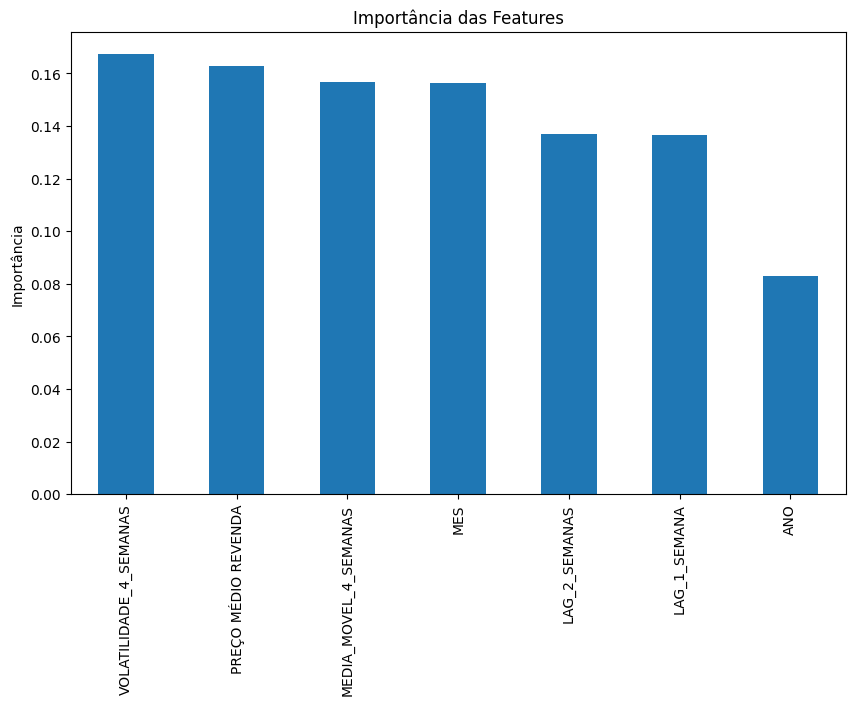

In [126]:
plt.figure(figsize=(10,6))

importancias.plot(kind="bar")

plt.title("Importância das Features")

plt.ylabel("Importância")

plt.show()